# Bump Chart

This section showcases the bump chart. It contains examples of how to create bump charts using the [datachart.charts.BumpChart](../../../references/charts/#datachart.charts.BumpChart) function.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-bump-chart), which maps common tasks to the parameter or style attribute that does the job.

As mentioned above, the bump charts are created using the `BumpChart` function found in the [datachart.charts](../../../references/charts/) module. Let's import it:

In [1]:
from datachart.charts import BumpChart

## Bump Chart Input Attributes

The `BumpChart` function accepts keyword arguments for chart configuration. The main argument is `data`, which contains the series to rank. Like the line chart, one series is a list of `{x, y}` points and several series are a list of such lists. The series do not need to share their `x` values: at every period the chart ranks the series that have a point there, and a series without one leaves a gap in its line.

```python
BumpChart(
    data=[                                              # The series to rank (or one list of points for a single series)
        [
            {
                "x": Union[int, float, str, datetime],  # The period
                "y": Union[int, float],                 # The value to rank, or the rank itself with rank_by="given"
            },
            ...
        ],
        ...
    ],
    rank_by=Optional[str],                              # "value_descending" (default), "value_ascending", or "given"
    show_labels=Optional[bool],                         # Whether to name each line at its end (True by default)
    label_position=Optional[str],                       # "start", "end" (default), or "both"
    show_markers=Optional[bool],                        # Whether to draw a marker at every period (True by default)
    line_curve=Optional[float],                         # 0 (default) draws straight segments, up to 1 for a full sigmoid
    style={                                             # The style of the lines (optional; a list for multiple series)
        "plot_bump_line_width":    Optional[float],     # The line width
        "plot_bump_marker":        Optional[str],       # The marker at every period
        "plot_bump_marker_size":   Optional[float],     # The marker size
        "plot_bump_label_padding": Optional[float],     # The gap between a line end and its label, in points
        "plot_line_color":         Optional[str],       # The line color
        "plot_line_style":         Optional[str],       # The line style
        "plot_line_alpha":         Optional[float],     # The line alpha
    },
    subtitle=Optional[str],                             # The series name, used as the end label (or list for multiple series)
    emphasis=Optional[str],                             # "highlight" or "background" (or list for multiple series)
    emphasis_rule=Optional[dict],                       # One-key rule on each series' ranks; "top" picks the best ranked
    title=Optional[str],                                # The chart title
    xlabel=Optional[str],                               # The x-axis label
    ylabel=Optional[str],                               # The y-axis label
    figsize=Optional[Tuple[float, float]],              # The figure size
    show_legend=Optional[bool],                         # Whether to show the legend (on only without end labels)
    show_grid=Optional[str],                            # Which grid lines to show
    show_values=Optional[bool],                         # Whether to print each point's original value
    subplots=Optional[bool],                            # Whether to draw each series in its own subplot
    max_cols=Optional[int],                             # The maximum number of subplot columns
    sharex=Optional[bool],                              # Whether the subplots share the x-axis
    sharey=Optional[bool],                              # Whether the subplots share the y-axis
    xmin=Optional[float],                               # The minimum x-axis value
    xmax=Optional[float],                               # The maximum x-axis value
    ymin=Optional[float],                               # The best rank shown
    ymax=Optional[float],                               # The worst rank shown
    vlines=Optional[Union[dict, List[dict]]],           # The vertical reference lines
    hlines=Optional[Union[dict, List[dict]]],           # The horizontal reference lines
    vspans=Optional[Union[dict, List[dict]]],           # The vertical reference bands
    hspans=Optional[Union[dict, List[dict]]],           # The horizontal reference bands
    texts=Optional[Union[dict, List[dict]]],            # The text annotations
    x=Optional[str],                                    # The key holding the period (default: "x")
    y=Optional[str],                                    # The key holding the value (default: "y")
)
```

For more details, see the [datachart.charts.BumpChart](../../../references/charts/#datachart.charts.BumpChart) function.

## Basics

The examples in this guide share one dataset: the populations of ten of the world's most populous countries in 1980, 1990, 2000, 2010, 2020 and 2023, in millions. The values are rounded from the estimates of the United Nations *World Population Prospects* and live in the hidden cell below. Population is a ranking story as much as a growth one: India passed China in 2023, Pakistan and Nigeria climbed past Brazil, and Russia and Japan slid down the table — and the order is exactly what a bump chart draws.

In [2]:
YEARS = [1980, 1990, 2000, 2010, 2020, 2023]

# population in millions, rounded from the UN World Population Prospects estimates
POPULATION = {
    "China": [982, 1135, 1264, 1348, 1424, 1426],
    "India": [697, 870, 1057, 1234, 1396, 1429],
    "United States": [227, 248, 282, 309, 336, 340],
    "Indonesia": [148, 182, 214, 244, 272, 278],
    "Pakistan": [80, 115, 154, 194, 227, 240],
    "Brazil": [122, 150, 176, 196, 213, 216],
    "Nigeria": [74, 95, 122, 160, 208, 224],
    "Bangladesh": [83, 107, 129, 148, 167, 173],
    "Russia": [139, 148, 146, 143, 145, 144],
    "Japan": [117, 124, 127, 128, 126, 124],
}
COUNTRIES = list(POPULATION)
population = [
    [{"x": year, "y": people} for year, people in zip(YEARS, POPULATION[country])]
    for country in COUNTRIES
]

The data is a list of series, one per country. Every series is a list of `{x, y}` points with the year as `x` and the population as `y` — the values, not the ranks; the chart ranks them for you:

In [3]:
{country: points[:2] for country, points in zip(COUNTRIES, population)}

{'China': [{'x': 1980, 'y': 982}, {'x': 1990, 'y': 1135}],
 'India': [{'x': 1980, 'y': 697}, {'x': 1990, 'y': 870}],
 'United States': [{'x': 1980, 'y': 227}, {'x': 1990, 'y': 248}],
 'Indonesia': [{'x': 1980, 'y': 148}, {'x': 1990, 'y': 182}],
 'Pakistan': [{'x': 1980, 'y': 80}, {'x': 1990, 'y': 115}],
 'Brazil': [{'x': 1980, 'y': 122}, {'x': 1990, 'y': 150}],
 'Nigeria': [{'x': 1980, 'y': 74}, {'x': 1990, 'y': 95}],
 'Bangladesh': [{'x': 1980, 'y': 83}, {'x': 1990, 'y': 107}],
 'Russia': [{'x': 1980, 'y': 139}, {'x': 1990, 'y': 148}],
 'Japan': [{'x': 1980, 'y': 117}, {'x': 1990, 'y': 124}]}

**Basic example.** Only the `data` argument is required to draw the bump chart. At every year the most populous country takes rank 1 at the top of the axis, and each line follows its country down or up the table. Add the `subtitle` attribute to name the lines: each name prints beside its line's last point, in the line's color, so no legend is needed.

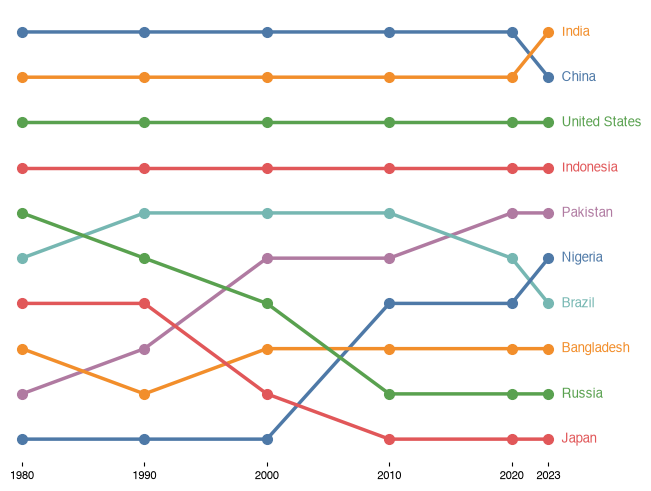

In [4]:
BumpChart(
    # add the data to the chart
    data=population,
    # name the lines at their ends
    subtitle=COUNTRIES,
).show()

## Customizing the Bump Chart

Every customization is either a keyword argument of `BumpChart` or a `plot_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                     | See |
| :------------------------------------------ | :---------------------------------------------------------------------- | :-- |
| add a title and axis labels                 | `title`, `xlabel`, `ylabel`                                             | [Title and axis labels](#title-and-axis-labels) |
| resize the figure or show the grid          | `figsize`, `show_grid`                                                  | [Figure size and grid](#figure-size-and-grid) |
| rank the lowest value first                 | `rank_by="value_ascending"`                                             | [Ranking](#ranking) |
| draw ranks I already have                   | `rank_by="given"`                                                       | [Ranking](#ranking) |
| name the lines at the start or at both ends | `label_position`                                                        | [End labels](#end-labels) |
| use a legend instead of end labels          | `show_labels=False`, `show_legend`                                      | [End labels](#end-labels) |
| curve the lines or hide the markers         | `line_curve`, `show_markers`                                            | [Line shape](#line-shape) |
| change the line width, markers, or colors   | `style={"plot_bump_line_width": ..., "plot_line_color": ...}`           | [Line style](#line-style) |
| print the values behind the ranks           | `show_values`, `value_format`, `value_step`                             | [Value labels](#value-labels) |
| highlight one series, mute the rest         | `emphasis`                                                              | [Emphasis](#emphasis) |
| highlight the best-ranked series            | `emphasis_rule={"top": n}`                                              | [Emphasis](#emphasis) |
| mark a year or shade the top of the table   | `vlines`, `hspans`                                                      | [Reference lines and bands](#reference-lines-and-bands) |
| draw every series on its own                | `subplots`                                                              | [Subplots](#subplots) |
| overlay or arrange several bump charts      | `Panel`, `Grid`                                                         | [Composing bump charts](#composing-bump-charts) |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `rank_by` | [`BUMP_RANK`](../../../references/constants/#datachart.constants.BUMP_RANK) |
| `label_position` | [`BUMP_LABEL_POSITION`](../../../references/constants/#datachart.constants.BUMP_LABEL_POSITION) |
| `emphasis` | [`EMPHASIS`](../../../references/constants/#datachart.constants.EMPHASIS) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `legend={"location": ..., "alignment": ...}` | [`LEGEND_LOCATION`](../../../references/constants/#datachart.constants.LEGEND_LOCATION), [`LEGEND_ALIGN`](../../../references/constants/#datachart.constants.LEGEND_ALIGN) |
| `show_grid` | [`SHOW_GRID`](../../../references/constants/#datachart.constants.SHOW_GRID) |
| `value_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT) |
| `aspect_ratio` | [`ASPECT_RATIO`](../../../references/constants/#datachart.constants.ASPECT_RATIO) |
| `scalex` | [`SCALE`](../../../references/constants/#datachart.constants.SCALE) |
| `xticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |

### Title and axis labels

To add the chart title and axis labels, add the `title`, `xlabel` and `ylabel` attributes.

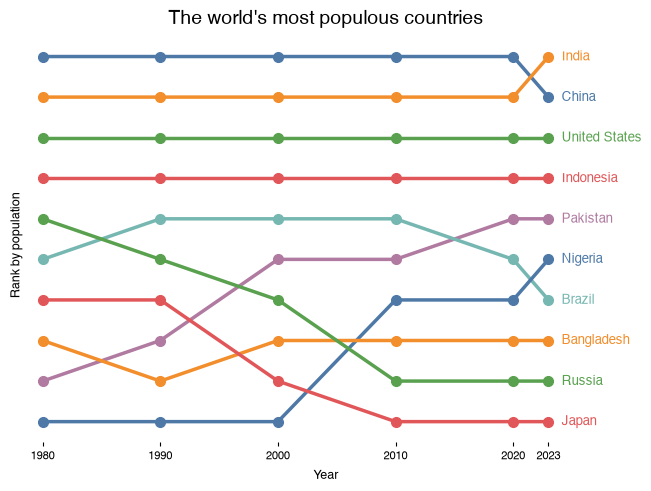

In [5]:
BumpChart(
    data=population,
    subtitle=COUNTRIES,
    # add the title
    title="The world's most populous countries",
    # add the x and y axis labels
    xlabel="Year",
    ylabel="Rank by population",
).show()

### Figure size and grid

To change the figure size, add the `figsize` attribute. The `figsize` attribute can be a tuple (width, height), values are in inches. The `datachart` package provides a [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE) constant, which contains predefined figure sizes. To change which grid lines show, add the `show_grid` attribute, which supports the values of the [datachart.constants.SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID) constant. The y-axis draws no line, ticks, or tick labels — the end labels already say which line is which — but a grid line still runs along every whole rank; the x-axis keeps its ticks without the axis line.

In [6]:
from datachart.constants import FIG_SIZE, SHOW_GRID

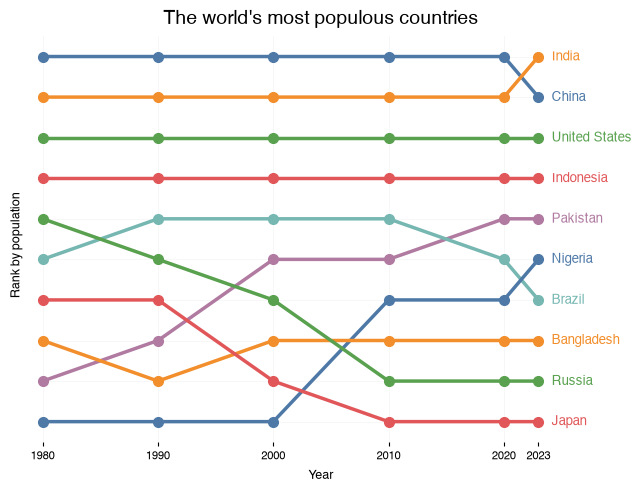

In [7]:
BumpChart(
    data=population,
    subtitle=COUNTRIES,
    title="The world's most populous countries",
    xlabel="Year",
    ylabel="Rank by population",
    # add to determine the figure size
    figsize=FIG_SIZE.FULL_MEDIUM,
    # add to show the grid lines on both axes
    show_grid=SHOW_GRID.BOTH,
).show()

### Ranking

The `rank_by` attribute says how `y` becomes a rank; the supported values are in the [datachart.constants.BUMP_RANK](../../../references/constants/#datachart.constants.BUMP_RANK) constant. The default, `VALUE_DESCENDING`, gives rank 1 to the highest value at each period. `VALUE_ASCENDING` gives it to the lowest — the natural order for lap times, golf scores, or prices. Ranking the ten countries from the smallest population up flips the table:

In [8]:
from datachart.constants import BUMP_RANK

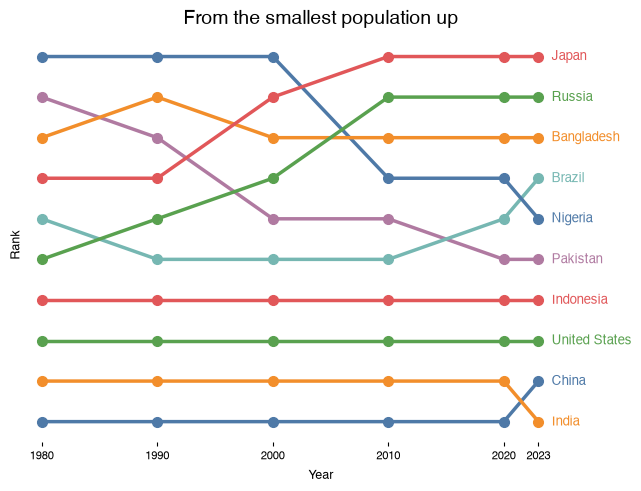

In [9]:
BumpChart(
    data=population,
    subtitle=COUNTRIES,
    # rank 1 is the smallest population of the ten
    rank_by=BUMP_RANK.VALUE_ASCENDING,
    title="From the smallest population up",
    xlabel="Year",
    ylabel="Rank",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

When the data already holds the ranks — a published league table, a poll position — use `GIVEN`: the chart draws `y` as the rank as it is, and raises an error on a rank that is not a positive whole number. Ties at a period keep the input order under the value rules; with `GIVEN` the ranks are yours to set.

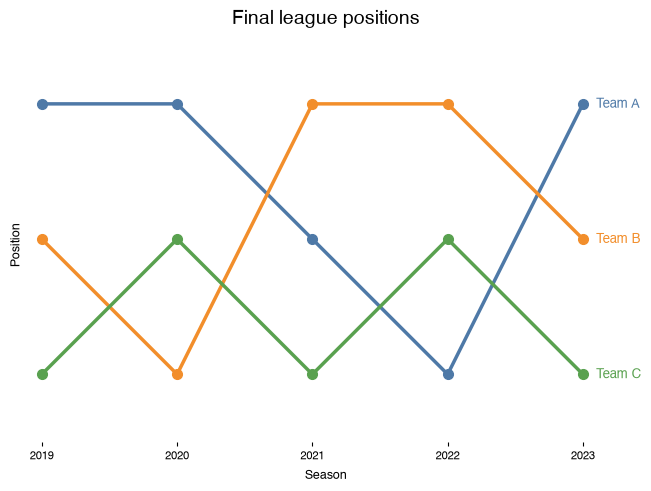

In [10]:
BumpChart(
    data=[
        [{"x": season, "y": rank} for season, rank in zip(range(2019, 2024), ranks)]
        for ranks in ([1, 1, 2, 3, 1], [2, 3, 1, 1, 2], [3, 2, 3, 2, 3])
    ],
    subtitle=["Team A", "Team B", "Team C"],
    # y is already the rank
    rank_by=BUMP_RANK.GIVEN,
    title="Final league positions",
    xlabel="Season",
    ylabel="Position",
).show()

### End labels

The `show_labels` attribute names every line with its `subtitle`, printed in the line's color; it is on by default. The `label_position` attribute picks the end that carries the name, from the [datachart.constants.BUMP_LABEL_POSITION](../../../references/constants/#datachart.constants.BUMP_LABEL_POSITION) constant: `END` (default), `START`, or `BOTH`. With labels at both ends the start and the end of every line read at a glance.

In [11]:
from datachart.constants import BUMP_LABEL_POSITION

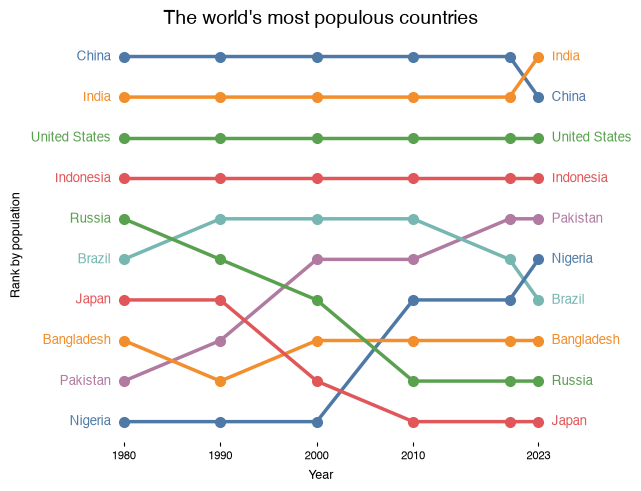

In [12]:
BumpChart(
    data=population,
    subtitle=COUNTRIES,
    # name every line at both ends
    label_position=BUMP_LABEL_POSITION.BOTH,
    title="The world's most populous countries",
    xlabel="Year",
    ylabel="Rank by population",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

The legend is off while the end labels name the lines. Turn the labels off with `show_labels=False` and the legend takes over; `show_legend` sets it explicitly either way.

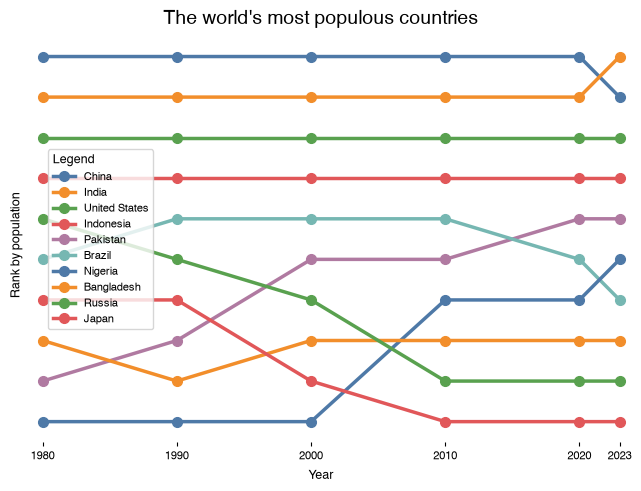

In [13]:
BumpChart(
    data=population,
    subtitle=COUNTRIES,
    # a legend instead of end labels
    show_labels=False,
    title="The world's most populous countries",
    xlabel="Year",
    ylabel="Rank by population",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Line shape

The `line_curve` attribute eases every segment between two periods along an S-shaped curve: `0` (default) draws straight segments and `1` a full sigmoid, with the values in between blending the two. The curve changes only the path between the points — every marker stays on its rank. The `show_markers` attribute hides the markers when the lines alone read better.

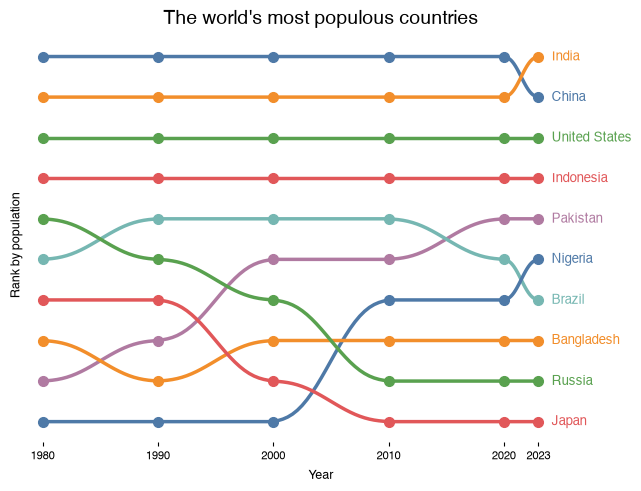

In [14]:
BumpChart(
    data=population,
    subtitle=COUNTRIES,
    # ease the lines between the years
    line_curve=0.8,
    title="The world's most populous countries",
    xlabel="Year",
    ylabel="Rank by population",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

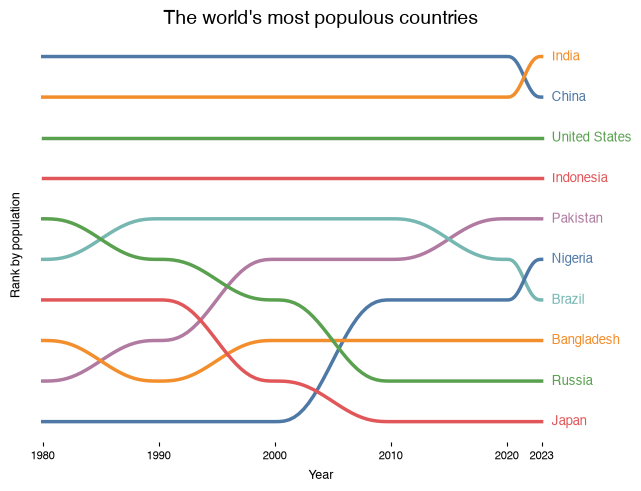

In [15]:
BumpChart(
    data=population,
    subtitle=COUNTRIES,
    line_curve=1,
    # lines without the markers
    show_markers=False,
    title="The world's most populous countries",
    xlabel="Year",
    ylabel="Rank by population",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Line style

To change the line style, add the `style` attribute with the corresponding attributes. The supported attributes are shown in the [datachart.typings.BumpStyleAttrs](../../../references/typings/#datachart.typings.BumpStyleAttrs) typing: `plot_bump_line_width`, `plot_bump_marker`, `plot_bump_marker_size` and `plot_bump_label_padding` set what is specific to a bump chart, while the color, alpha and dash come from the `plot_line_*` attributes. A single dictionary applies to every series; a list, aligned with `data`, styles each on its own. The example draws thin square-marked lines and colors the two giants apart from the rest.

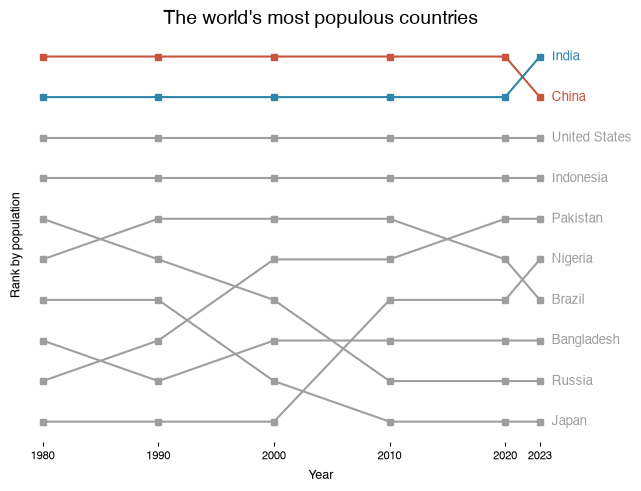

In [16]:
BumpChart(
    data=population,
    subtitle=COUNTRIES,
    # one style per series: China and India in their own colors, the rest grey
    style=[
        {
            "plot_bump_line_width": 1.5,
            "plot_bump_marker": "s",
            "plot_bump_marker_size": 5,
            "plot_line_color": {"China": "#C8553D", "India": "#2E86AB"}.get(country, "#9E9E9E"),
        }
        for country in COUNTRIES
    ],
    title="The world's most populous countries",
    xlabel="Year",
    ylabel="Rank by population",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Value labels

A rank hides the size of the gaps. To print the value behind every rank beside its marker, add the `show_values` attribute: the labels show the original `y`, not the rank. `value_format` controls the formatting ([datachart.constants.VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT)) and `value_step` labels every Nth period (by default the step keeps neighbouring labels apart).

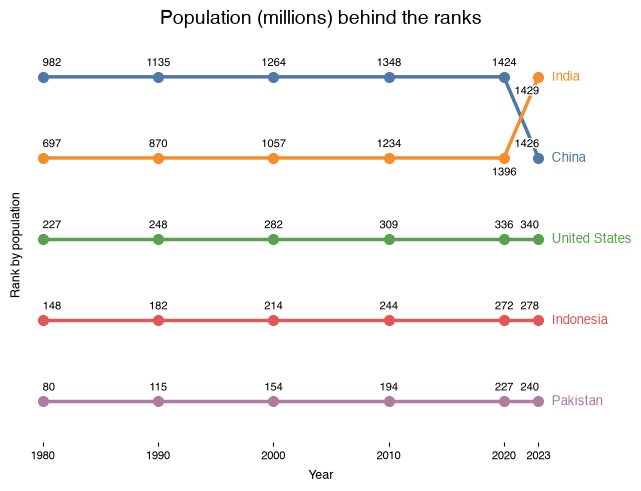

In [17]:
from datachart.constants import VALUE_FORMAT

BumpChart(
    # five countries keep the labels legible
    data=population[:5],
    subtitle=COUNTRIES[:5],
    # print the population behind every rank
    show_values=True,
    value_format=VALUE_FORMAT.INTEGER,
    title="Population (millions) behind the ranks",
    xlabel="Year",
    ylabel="Rank by population",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Emphasis

A bump chart with ten lines usually tells the story of one or two of them. The `emphasis` attribute expresses that directly: `"highlight"` brings a line to the front, `"background"` mutes it (the theme's muted color at a lower alpha, and a muted end label), and `None` leaves it unchanged. `emphasis` is a list aligned with `data`, just like `subtitle` and `style`; the role strings are also available as the [datachart.constants.EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) constants. See the [Highlighting](../../styling/highlighting/) guide for how emphasis works across all chart types and themes.

In [18]:
from datachart.constants import EMPHASIS

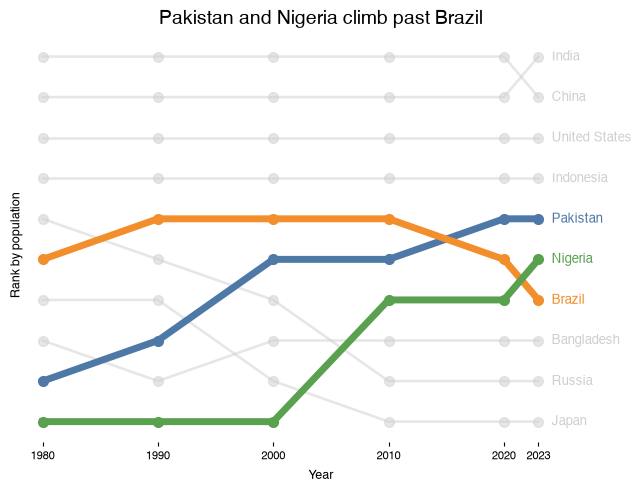

In [19]:
BumpChart(
    data=population,
    subtitle=COUNTRIES,
    # follow the countries that climbed past Brazil
    emphasis=[
        EMPHASIS.HIGHLIGHT if country in ("Pakistan", "Nigeria", "Brazil") else EMPHASIS.BACKGROUND
        for country in COUNTRIES
    ],
    title="Pakistan and Nigeria climb past Brazil",
    xlabel="Year",
    ylabel="Rank by population",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

To pick the lines from the data instead, pass `emphasis_rule`, a one-key rule that highlights every series whose summary matches and mutes the rest. On a bump chart the rule reads each series' ranks, and `{"top": n}` means the `n` best-ranked series — the lowest rank numbers — while `{"bottom": n}` picks the worst. The summary is the mean rank by default; a `"by"` key picks `"median"`, `"min"`, `"max"`, or `"sum"` instead. The thresholds `{"above": v}`, `{"below": v}` and `{"between": (lo, hi)}` compare the rank number itself, so `{"below": 4}` keeps the series that ranked in the top three on average. An explicit `emphasis` role wins over the rule.

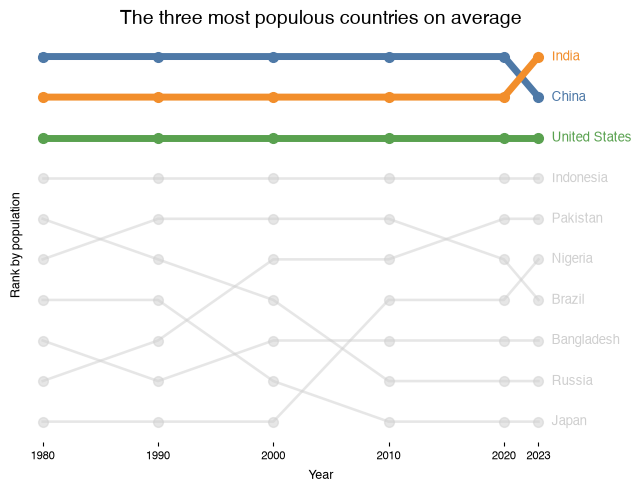

In [20]:
BumpChart(
    data=population,
    subtitle=COUNTRIES,
    # the three countries with the best mean rank
    emphasis_rule={"top": 3},
    title="The three most populous countries on average",
    xlabel="Year",
    ylabel="Rank by population",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Reference lines and bands

Reference lines and bands take the rank as their `y`. To add vertical lines, add the `vlines` attribute with the [datachart.typings.VLineSettingAttrs](../../../references/typings/#datachart.typings.VLineSettingAttrs) typing; to shade a horizontal band, add the `hspans` attribute with the [datachart.typings.HSpanSettingAttrs](../../../references/typings/#datachart.typings.HSpanSettingAttrs) typing — the other directions work the same way through `hlines` and `vspans`. The band below shades the top three of the table and the line marks the turn of the millennium; a single line or band applies once to the whole figure.

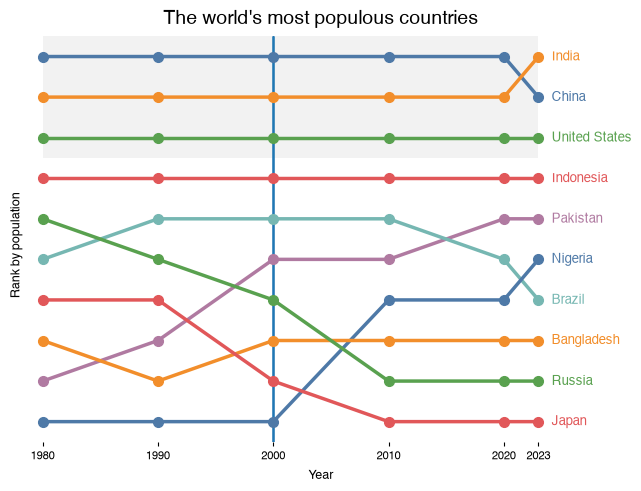

In [21]:
BumpChart(
    data=population,
    subtitle=COUNTRIES,
    # shade the top three ranks and mark the year 2000
    hspans={"ymin": 0.5, "ymax": 3.5, "label": "top three"},
    vlines={"x": 2000},
    title="The world's most populous countries",
    xlabel="Year",
    ylabel="Rank by population",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Multiple Bump Charts

### Subplots

The `subplots` attribute draws each series in its own subplot. The ranks are still computed over every series, so each subplot shows its country's place among all ten. The `subtitle` becomes the subplot title and the `title`, `xlabel` and `ylabel` are positioned to be global for all charts. The `max_cols` attribute limits the number of columns, and `sharex` and `sharey` share an axis across the subplots.

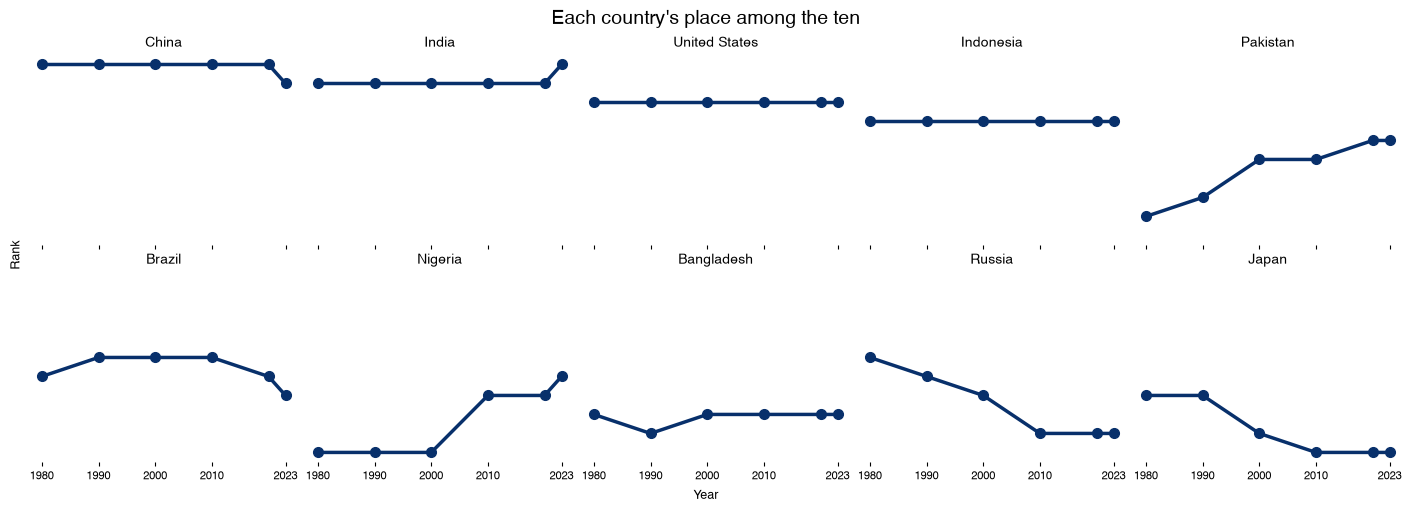

In [22]:
BumpChart(
    data=population,
    subtitle=COUNTRIES,
    # one country per subplot, ranked among all ten
    subplots=True,
    max_cols=5,
    sharex=True,
    sharey=True,
    show_labels=False,
    title="Each country's place among the ten",
    xlabel="Year",
    ylabel="Rank",
    figsize=(14, 5),
).show()

### Composing bump charts

A bump figure composes like a line chart. [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) overlays it with other figures on shared axes; every bump figure keeps the ranks it computed, so a panel overlays rankings that share a scale — here the table's top five and, drawn with dashed lines, the rest, both drawn from ranks computed over all ten. [datachart.utils.Grid](../../../references/utils/#datachart.utils.Grid) arranges bump figures next to other figures.

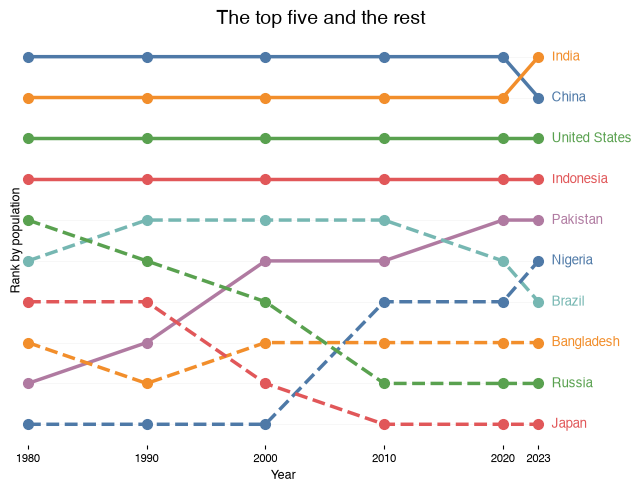

In [23]:
from datachart.charts import BarChart
from datachart.constants import LINE_STYLE
from datachart.utils import Grid, Panel

# the ten ranks of every year, split by the 2023 table into the top five and the rest
ranks = {country: [] for country in COUNTRIES}
for i, year in enumerate(YEARS):
    ordered = sorted(COUNTRIES, key=lambda c: -POPULATION[c][i])
    for rank, country in enumerate(ordered, start=1):
        ranks[country].append(rank)
top = [c for c in COUNTRIES if ranks[c][-1] <= 5]
rest = [c for c in COUNTRIES if ranks[c][-1] > 5]


def ranked(countries):
    return [[{"x": y, "y": r} for y, r in zip(YEARS, ranks[c])] for c in countries]


Panel(
    [
        BumpChart(data=ranked(top), subtitle=top, rank_by=BUMP_RANK.GIVEN),
        BumpChart(
            data=ranked(rest),
            subtitle=rest,
            rank_by=BUMP_RANK.GIVEN,
            style={"plot_line_style": LINE_STYLE.DASHED},
        ),
    ],
    title="The top five and the rest",
    xlabel="Year",
    ylabel_left="Rank by population",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

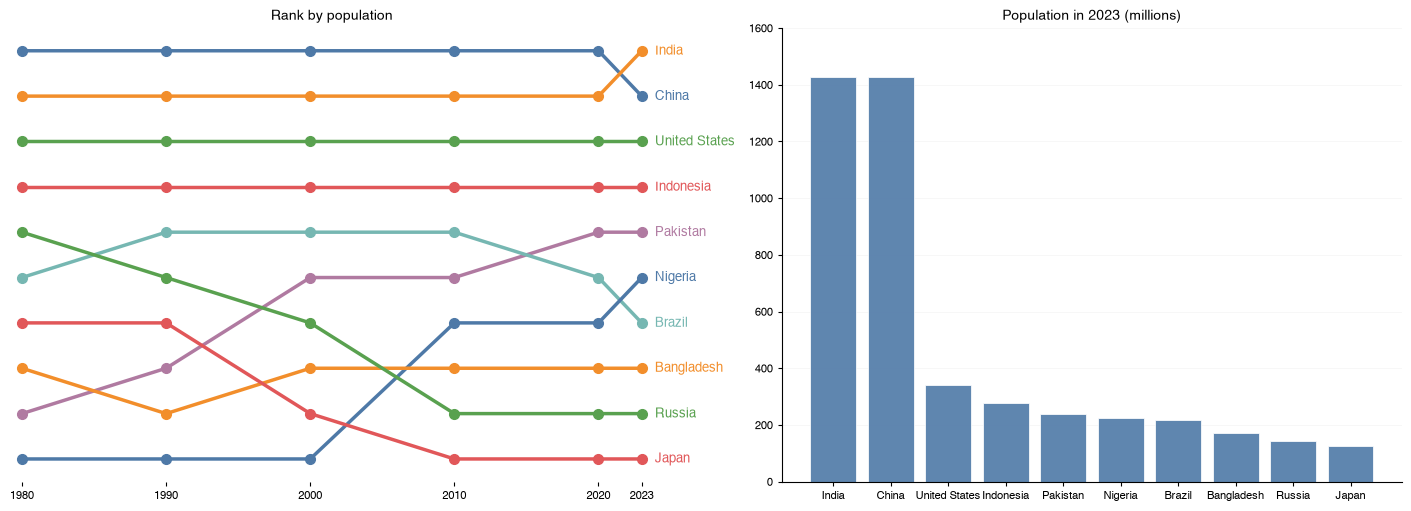

In [24]:
bump = BumpChart(data=population, subtitle=COUNTRIES, title="Rank by population")
bars = BarChart(
    data=[{"label": country, "y": POPULATION[country][-1]} for country in COUNTRIES],
    title="Population in 2023 (millions)",
    sort="descending",
)
Grid([[bump, bars]], figsize=(14, 5)).show()

## Additional Features

### Custom data keys

By default the chart reads the `x` and `y` keys of every point. When the data uses other names, add the `x` and `y` attributes with the key names — the hidden cell below holds the same population as `year`/`millions` records.

In [25]:
records = [
    [{"year": year, "millions": people} for year, people in zip(YEARS, POPULATION[country])]
    for country in COUNTRIES
]

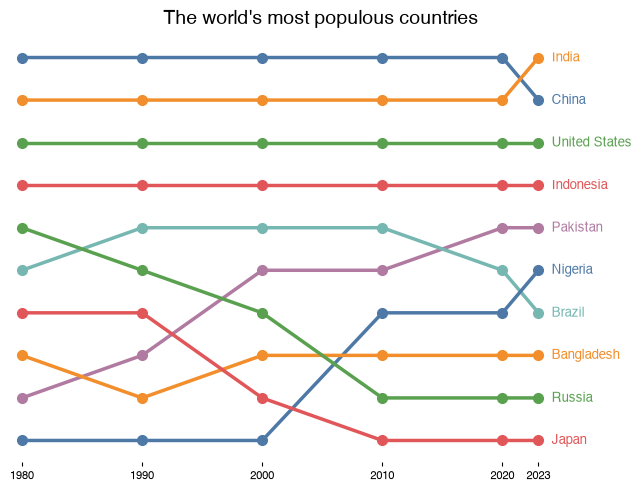

In [26]:
BumpChart(
    data=records,
    # read the year and millions keys instead of x and y
    x="year",
    y="millions",
    subtitle=COUNTRIES,
    title="The world's most populous countries",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Datetime axis

The periods may be real temporal objects — `datetime`, `date`, `numpy.datetime64`, or pandas `Timestamp` — instead of numbers, and the axis then reads as time: the points sit at their elapsed time, so uneven periods keep their spacing. `xticks_format` takes a [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) member or any `strftime` pattern. Date strings are not parsed; they draw as categories, in the order they first appear.

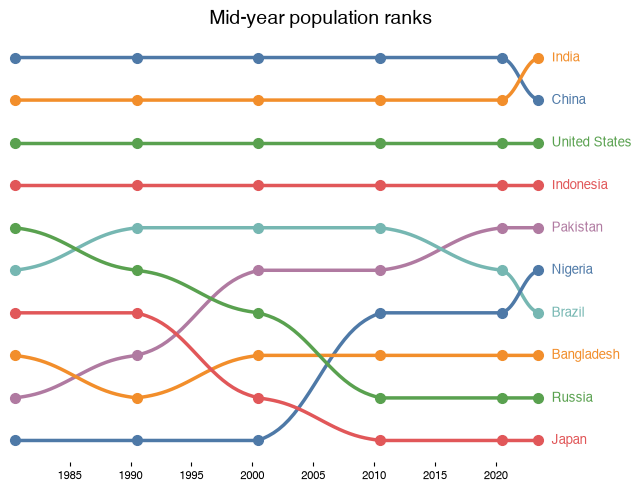

In [27]:
from datetime import date

from datachart.constants import DATE_FORMAT

BumpChart(
    data=[
        [{"x": date(year, 7, 1), "y": people} for year, people in zip(YEARS, POPULATION[country])]
        for country in COUNTRIES
    ],
    subtitle=COUNTRIES,
    line_curve=0.6,
    xticks_format=DATE_FORMAT.YEAR,
    title="Mid-year population ranks",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Themes

A theme sets the palette, the line width, and the furniture of every chart at once; see the [Theme Gallery](../../styling/theme-gallery/) for the whole suite under each. Apply one with [datachart.config.Config.set_theme](../../../references/config/#datachart.config.Config.set_theme) from the [datachart.constants.THEME](../../../references/constants/#datachart.constants.THEME) constant, and reset the configuration afterwards so the following charts draw in the default again.

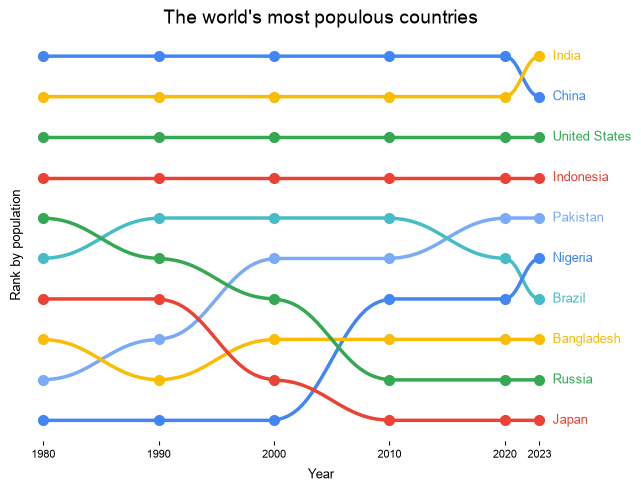

In [28]:
from datachart.config import config
from datachart.constants import THEME

config.set_theme(THEME.MATERIAL)
figure = BumpChart(
    data=population,
    subtitle=COUNTRIES,
    line_curve=0.8,
    title="The world's most populous countries",
    xlabel="Year",
    ylabel="Rank by population",
    figsize=FIG_SIZE.FULL_MEDIUM,
)
config.reset_config()
figure.show()

## Saving the Chart as an Image

To save the chart as an image, use the [datachart.utils.save_figure](../../../references/utils#datachart.utils.save_figure) function.

In [29]:
from datachart.utils import save_figure

figure = BumpChart(
    data=population,
    subtitle=COUNTRIES,
    title="The world's most populous countries",
    xlabel="Year",
    ylabel="Rank by population",
)
save_figure(figure, "./fig_bump_chart.png", dpi=300)

['./fig_bump_chart.png']

The figure should be saved in the current working directory.

## Real-World Examples

The following examples put the features above to work. Each one states what it shows; any derived data lives in a hidden cell.

### Example 1: India Overtakes China (Emphasis, Curves, and Value Labels)

For four decades the top of the table did not move; in 2023 India's population passed China's. Limited to the top four countries, highlighted and curved, with the populations printed behind the ranks, the chart shows how long the order held and how narrow the final crossing was.

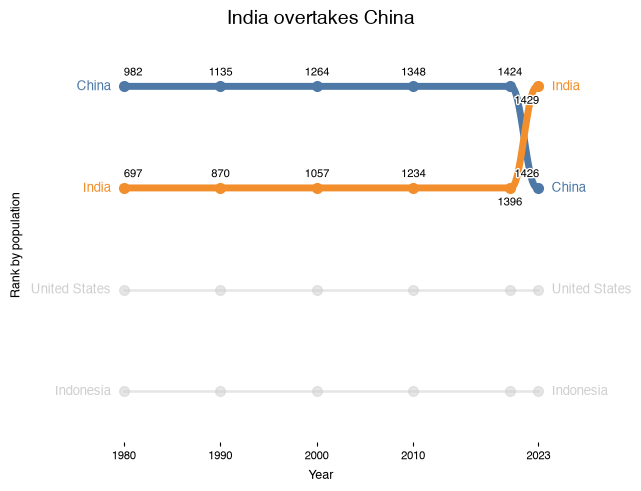

In [30]:
BumpChart(
    data=population[:4],
    subtitle=COUNTRIES[:4],
    emphasis=[EMPHASIS.HIGHLIGHT, EMPHASIS.HIGHLIGHT, EMPHASIS.BACKGROUND, EMPHASIS.BACKGROUND],
    line_curve=1,
    show_values=True,
    value_format=VALUE_FORMAT.INTEGER,
    label_position=BUMP_LABEL_POSITION.BOTH,
    title="India overtakes China",
    xlabel="Year",
    ylabel="Rank by population",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Example 2: A Season's League Table (Given Ranks, Gaps, and a Grid)

Illustrative weekly positions of six clubs over a ten-week stretch, with one club's week-6 match postponed so it holds no position that week. The positions are already ranks, so `rank_by` is `GIVEN`, and the postponed week leaves a gap in the club's line. The grid pairs the table with the final positions as a sorted bar chart.

In [31]:
CLUBS = ["Rovers", "United", "City", "Athletic", "Wanderers", "Albion"]
POSITIONS = {
    "Rovers": [1, 1, 2, 2, 1, 1, 1, 2, 1, 1],
    "United": [2, 3, 1, 1, 2, 2, 3, 1, 2, 2],
    "City": [4, 2, 3, 4, 3, None, 2, 3, 3, 4],
    "Athletic": [3, 4, 4, 3, 5, 3, 4, 4, 4, 3],
    "Wanderers": [6, 5, 5, 6, 4, 4, 5, 5, 6, 5],
    "Albion": [5, 6, 6, 5, 6, 5, 6, 6, 5, 6],
}
table = [
    [{"x": week, "y": position} for week, position in enumerate(POSITIONS[club], start=1) if position is not None]
    for club in CLUBS
]

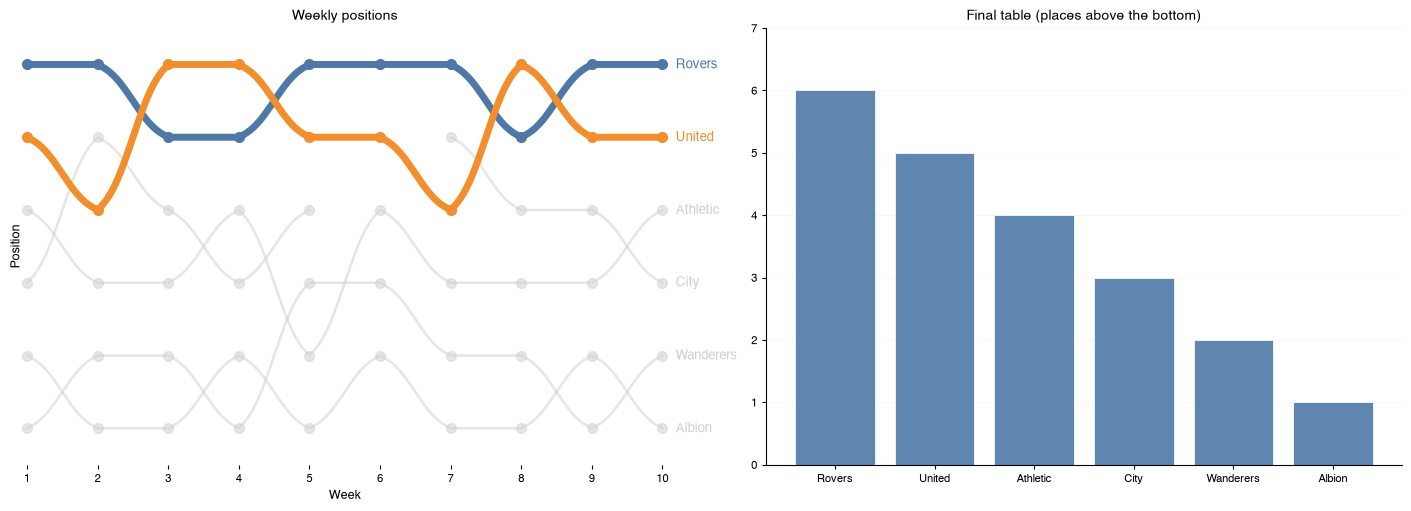

In [32]:
league = BumpChart(
    data=table,
    subtitle=CLUBS,
    rank_by=BUMP_RANK.GIVEN,
    line_curve=0.5,
    emphasis_rule={"top": 2},
    title="Weekly positions",
    xlabel="Week",
    ylabel="Position",
)
final = BarChart(
    data=[{"label": club, "y": 7 - POSITIONS[club][-1]} for club in CLUBS],
    title="Final table (places above the bottom)",
    sort="descending",
)
Grid([[league, final]], figsize=(14, 5)).show()